In [4]:
 %tensorflow_version 2.x  
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras import models

import os
import tensorflow as tf
import numpy as np
from numpy import expand_dims
import matplotlib.pyplot as plt




TensorFlow 2.x selected.


In [5]:
tf.__version__


'2.0.0'

**FASHION MNIST with Dense layer only:**

4423680/4422102 [==============================] - 0s 0us/step
Train data Shape:(60000, 28, 28)
9
Ankle boot


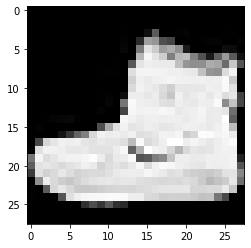

In [10]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']  # To get index converted to literal labels

print("Train data Shape:"+ str(train_images.shape)) #60000 images of 28X28 pixels
print(train_labels[0]) # 10 classes, but labels are 0 to 9 
plt.imshow(train_images[0], cmap="Greys_r")
print(class_names[train_labels[0]])


data = tf.data.Dataset.from_tensor_slices(
    (train_images.reshape([-1, 28, 28, 1]).astype(np.float32) / 255, train_labels.astype(np.int32)))
data = data.shuffle(buffer_size=60000).batch(128).repeat()

# note: we batch the test data, but do not shuffle/repeat
test_data = tf.data.Dataset.from_tensor_slices(
    (test_images.reshape([-1, 28, 28, 1]).astype(np.float32) / 255, test_labels.astype(np.int32))).batch(128)

In [0]:
train_steps = 2500

n_h = 256
layer_list = [tf.keras.layers.Flatten(input_shape=(28, 28)),       #To reshape to 784
              tf.keras.layers.Dense(n_h, activation=tf.nn.relu),
              tf.keras.layers.Dense(n_h//2, activation=tf.nn.relu),
              tf.keras.layers.Dense(10)]  # default is no activation - logits
model = tf.keras.Sequential(layer_list)

opt = tf.optimizers.SGD(0.5)
# from_logits = True!! #neverforget . 
#from_logits: Whether y_pred is expected to be a logits tensor. 
#By default, we assume that y_pred encodes a probability distribution. Note: Using from_logits=True may be more numerically stable.
loss_fn = tf.losses.SparseCategoricalCrossentropy(from_logits=True)
train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()


In [0]:
def train(): 
  for step, (img_batch, lbl_batch) in enumerate(data):
      if step > train_steps:
          break

      # print("Image_batch shape:"+ str(img_batch.shape)+ " lbl_batch shape:"+ str(lbl_batch.shape))
      with tf.GradientTape() as tape:
         logits = model(img_batch)
          # loss format is generally: first argument targets, second argument outputs
         xent = loss_fn(lbl_batch, logits)

     # if you didn't build the model, it is important that you get the variables
     # AFTER the model has been called the first time
      varis = model.trainable_variables
      grads = tape.gradient(xent, varis)

      opt.apply_gradients(zip(grads, varis))
    
      train_acc_metric(lbl_batch, logits)
    
      if not step % 100:
          # this is different from before. there, we only evaluated accuracy
         # for one batch. Now, we always average over 100 batches
         print("Step: {} Loss: {} Accuracy: {}".format(step, xent, train_acc_metric.result()))
         train_acc_metric.reset_states()

In [0]:
# this is very convenient -- before, we usually had code that
# evaluates the whole test set at once -- this won't work for
# large datasets/models. With metrics, we can just iterate
# over the data and the metric takes care of averaging etc.

def test(): 
    test_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
    for img_batch, lbl_batch in test_data:
         test_acc_metric(lbl_batch, model(img_batch))
    print("Test acc: {}".format(test_acc_metric.result()))

In [14]:
train()
test()

Step: 0 Loss: 2.3476369380950928 Accuracy: 0.1015625
Step: 100 Loss: 0.7252846956253052 Accuracy: 0.5520312786102295
Step: 200 Loss: 0.8552073836326599 Accuracy: 0.7555468678474426
Step: 300 Loss: 0.5803585052490234 Accuracy: 0.7763281464576721
Step: 400 Loss: 0.5583705902099609 Accuracy: 0.7892187237739563
Step: 500 Loss: 0.40946897864341736 Accuracy: 0.8183740377426147
Step: 600 Loss: 0.40288299322128296 Accuracy: 0.8237500190734863
Step: 700 Loss: 0.4196254312992096 Accuracy: 0.8310156464576721
Step: 800 Loss: 0.3827774226665497 Accuracy: 0.839062511920929
Step: 900 Loss: 0.41901475191116333 Accuracy: 0.8462499976158142
Step: 1000 Loss: 0.358526349067688 Accuracy: 0.854479968547821
Step: 1100 Loss: 0.4425699710845947 Accuracy: 0.8526562452316284
Step: 1200 Loss: 0.4705878794193268 Accuracy: 0.8502343893051147
Step: 1300 Loss: 0.34291505813598633 Accuracy: 0.8647656440734863
Step: 1400 Loss: 0.32939085364341736 Accuracy: 0.8584374785423279
Step: 1500 Loss: 0.22004222869873047 Accurac

NOTE: Fashion_mnist in assignment-1 with a dense network of 784-256-256-10(2 hidden layers) gave a test accuracy of 0.71670001745224

**FASHION_MNIST with Adam optimiser for dense layers:**

In [15]:
opt = tf.optimizers.Adam()
train()
test()

Step: 0 Loss: 0.31003350019454956 Accuracy: 0.890625
Step: 100 Loss: 0.2538871467113495 Accuracy: 0.8869531154632568
Step: 200 Loss: 0.2618078887462616 Accuracy: 0.8977344036102295
Step: 300 Loss: 0.22832247614860535 Accuracy: 0.8968750238418579
Step: 400 Loss: 0.31673675775527954 Accuracy: 0.8883593678474426
Step: 500 Loss: 0.27854350209236145 Accuracy: 0.8954417109489441
Step: 600 Loss: 0.24607068300247192 Accuracy: 0.8999218940734863
Step: 700 Loss: 0.1697448492050171 Accuracy: 0.8995312452316284
Step: 800 Loss: 0.23629872500896454 Accuracy: 0.8985937237739563
Step: 900 Loss: 0.198142409324646 Accuracy: 0.8986718654632568
Step: 1000 Loss: 0.2497139573097229 Accuracy: 0.8997493982315063
Step: 1100 Loss: 0.14889907836914062 Accuracy: 0.9036718606948853
Step: 1200 Loss: 0.3514517843723297 Accuracy: 0.9053906202316284
Step: 1300 Loss: 0.24153771996498108 Accuracy: 0.9020312428474426
Step: 1400 Loss: 0.2890196740627289 Accuracy: 0.900390625
Step: 1500 Loss: 0.16739168763160706 Accuracy: 

Observation: Training with Adam optimiser reached 93% accuracy within 500 steps, where as SGD took 2500 steps

**FASHION MNIST with CNN**

In [0]:
#keras.layers.Conv2D(filters, kernel_size, strides=(1, 1), padding='valid', data_format=None, dilation_rate=(1, 1), activation=None, use_bias=True, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, bias_constraint=None)
def model1(input_shape):
  layer_list = [tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape = input_shape),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Flatten(),
                  tf.keras.layers.Dense(10)]  # default is no activation - logits
  model = tf.keras.Sequential(layer_list)
  return model

In [17]:
input_shape = (28,28,1)

model = model1(input_shape)
model.summary()
train()
test()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 28, 28, 32)        320       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 14, 14, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 7, 7, 64)          0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 7, 7, 128)         73856     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 3, 3, 128)         0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 1152)             

Observations: 
* With kernel size (3X3), number of filters 32-64-128 the  test accuracy was around 91%
* With kernel size (5X5) the test accuracy was almost same, but training accuracy would increase slightly +2%
* Having number of filters 16-32-64 gave test accuracy of around 90%
* With kernel size (1X1), test accuracy was 80% 



Conclusion: Best combo (3X3) with 32-64-128 filters . (among tested combinations)


**CIFAR10 with CNN**

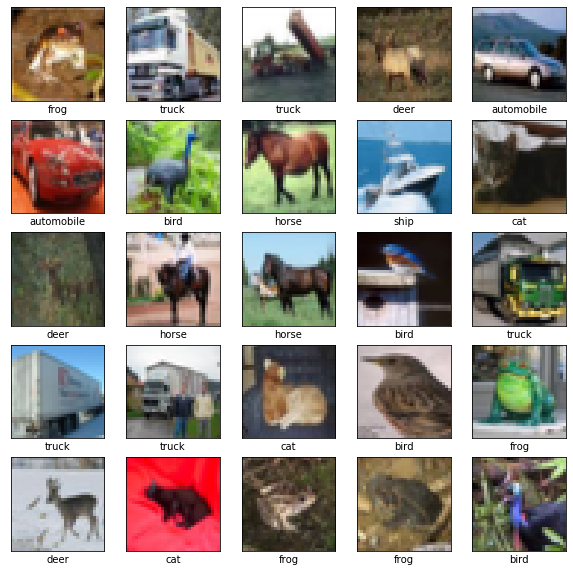

Train data Shape:(50000, 32, 32, 3)
Train label shape:(50000, 1)


In [5]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

print("Train data Shape:"+ str(train_images.shape)) #50000 images of 32X32 pixels 3 channels(RGB)
print("Train label shape:"+ str(train_labels.shape))
data = tf.data.Dataset.from_tensor_slices(
    (train_images.reshape([-1, 32, 32, 3]).astype(np.float32) / 255, train_labels.reshape((-1,)).astype(np.int32)))
data = data.shuffle(buffer_size=50000).batch(128).repeat()

# note: we batch the test data, but do not shuffle/repeat
test_data = tf.data.Dataset.from_tensor_slices(
    (test_images.reshape([-1, 32, 32, 3]).astype(np.float32) / 255, test_labels.reshape((-1,)).astype(np.int32))).batch(128)


In [0]:
train_steps = 2500
opt = tf.optimizers.Adam()
loss_fn = tf.losses.SparseCategoricalCrossentropy(from_logits=True)
train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()


In [0]:
#keras.layers.Conv2D(filters, kernel_size, strides=(1, 1), padding='valid', data_format=None, dilation_rate=(1, 1), activation=None, use_bias=True, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, bias_constraint=None)
def model1(input_shape):
  layer_list = [tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape = input_shape),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Flatten(),
                  tf.keras.layers.Dense(10)]  # default is no activation - logits
  model = tf.keras.Sequential(layer_list)
  return model

In [21]:
input_shape = (32,32,3)
#keras.layers.Conv2D(filters, kernel_size, strides=(1, 1), padding='valid', data_format=None, dilation_rate=(1, 1), activation=None, use_bias=True, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, bias_constraint=None)
model = model1(input_shape)
train()
test()

Step: 0 Loss: 2.3026115894317627 Accuracy: 0.0859375
Step: 100 Loss: 2.2998158931732178 Accuracy: 0.10601562261581421
Step: 200 Loss: 2.1353063583374023 Accuracy: 0.19249999523162842
Step: 300 Loss: 2.168051242828369 Accuracy: 0.24703125655651093
Step: 400 Loss: 2.125575542449951 Accuracy: 0.2708594799041748
Step: 500 Loss: 1.905402421951294 Accuracy: 0.30156248807907104
Step: 600 Loss: 1.8891615867614746 Accuracy: 0.31617188453674316
Step: 700 Loss: 1.8833750486373901 Accuracy: 0.34156250953674316
Step: 800 Loss: 1.8583881855010986 Accuracy: 0.351317435503006
Step: 900 Loss: 1.733607292175293 Accuracy: 0.36531248688697815
Step: 1000 Loss: 1.7839734554290771 Accuracy: 0.3660937547683716
Step: 1100 Loss: 1.9287183284759521 Accuracy: 0.3824218809604645
Step: 1200 Loss: 1.7599787712097168 Accuracy: 0.3790777921676636
Step: 1300 Loss: 1.607650637626648 Accuracy: 0.38820311427116394
Step: 1400 Loss: 1.6732020378112793 Accuracy: 0.39671874046325684
Step: 1500 Loss: 1.7024474143981934 Accurac

Observations:
* With model1 , accuracy was around 44%

In [0]:
#keras.layers.Conv2D(filters, kernel_size, strides=(1, 1), padding='valid', data_format=None, dilation_rate=(1, 1), activation=None, use_bias=True, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, bias_constraint=None)
def model2(input_shape):
  layer_list = [tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape = input_shape),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.Flatten(),
                  tf.keras.layers.Dense(64),
                  tf.keras.layers.Dense(10, activation= 'softmax')]  # default is no activation - logits
  model = tf.keras.Sequential(layer_list)
  return model

In [0]:
def plotLosses(history):  
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

In [0]:
def plotAccuracies(history):  
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0.5, 1])
    plt.legend(loc='upper right')
    plt.show()

In [0]:
def run_model(model):
  model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  history = model.fit(train_images, train_labels, epochs=10, batch_size= 128, 
                    validation_data=(test_images, test_labels))
  plotLosses(history)
  plotAccuracies(history)

Train on 50000 samples, validate on 10000 samples
Epoch 1/10
50000/50000 [==============================] - 4s 77us/sample - loss: 1.4767 - accuracy: 0.4724 - val_loss: 1.2518 - val_accuracy: 0.5522
Epoch 2/10
50000/50000 [==============================] - 3s 59us/sample - loss: 1.0855 - accuracy: 0.6209 - val_loss: 1.0035 - val_accuracy: 0.6507
Epoch 3/10
50000/50000 [==============================] - 3s 59us/sample - loss: 0.9288 - accuracy: 0.6736 - val_loss: 0.8989 - val_accuracy: 0.6911
Epoch 4/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.8219 - accuracy: 0.7129 - val_loss: 0.8694 - val_accuracy: 0.6945
Epoch 5/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.7435 - accuracy: 0.7421 - val_loss: 0.8432 - val_accuracy: 0.7153
Epoch 6/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.6780 - accuracy: 0.7627 - val_loss: 0.8119 - val_accuracy: 0.7233
Epoch 7/10
50000/50000 [==============================] 

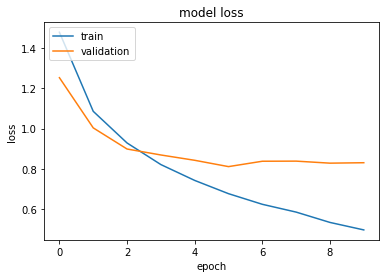

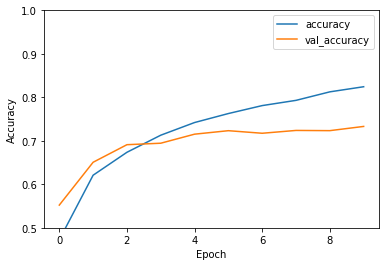

In [26]:
input_shape = (32,32,3)
model = model2(input_shape)
run_model(model)

Observation:
* The test accuracy isnt converging with training accuracy - which can imply that the model is overfitting with training data. 
* Try Regularisation ? Data Augmentation?

**DROPOUT**

In [0]:
#Model with dropouts to avoid overfitting
def model3(input_shape):
  layer_list = [tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape = input_shape),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Dropout(0.25), #Addition of layer herer
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.Flatten(),
                  tf.keras.layers.Dense(64),
                  tf.keras.layers.Dense(10, activation= 'softmax')]  
  model = tf.keras.Sequential(layer_list)
  return model

Train on 50000 samples, validate on 10000 samples
Epoch 1/10
50000/50000 [==============================] - 4s 77us/sample - loss: 1.4864 - accuracy: 0.4611 - val_loss: 1.2419 - val_accuracy: 0.5552
Epoch 2/10
50000/50000 [==============================] - 3s 62us/sample - loss: 1.0821 - accuracy: 0.6211 - val_loss: 0.9783 - val_accuracy: 0.6581
Epoch 3/10
50000/50000 [==============================] - 3s 63us/sample - loss: 0.9270 - accuracy: 0.6757 - val_loss: 0.9051 - val_accuracy: 0.6858
Epoch 4/10
50000/50000 [==============================] - 3s 63us/sample - loss: 0.8395 - accuracy: 0.7079 - val_loss: 0.8439 - val_accuracy: 0.7077
Epoch 5/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.7654 - accuracy: 0.7336 - val_loss: 0.8137 - val_accuracy: 0.7168
Epoch 6/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.7157 - accuracy: 0.7488 - val_loss: 0.8135 - val_accuracy: 0.7159
Epoch 7/10
50000/50000 [==============================] 

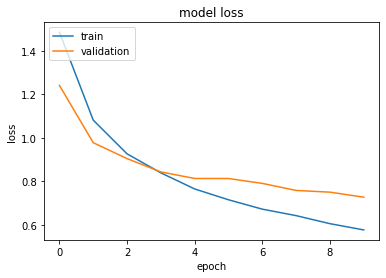

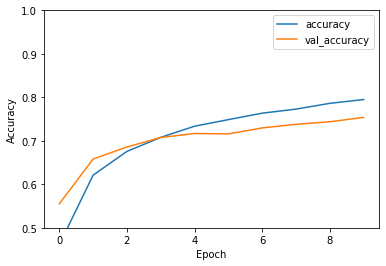

In [28]:
input_shape = (32,32,3)
model = model3(input_shape)
run_model(model)

Observation: 
* Even a single layer of dropout(0.25) decreased the overfitting.( We can see that the loss is not increasing with complexity)

In [0]:
#Model with dropouts to avoid overfitting
def model4(input_shape):
  layer_list = [tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape = input_shape),
                  tf.keras.layers.MaxPooling2D(2,2),
                  # tf.keras.layers.Dropout(0.25), #Addition of layer here
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Dropout(0.25), #Addition of layer here
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.Flatten(),
                  tf.keras.layers.Dense(64),
                  tf.keras.layers.Dropout(0.5),
                  tf.keras.layers.Dense(10, activation= 'softmax')]  
  model = tf.keras.Sequential(layer_list)
  return model

Train on 50000 samples, validate on 10000 samples
Epoch 1/10
50000/50000 [==============================] - 4s 74us/sample - loss: 1.6166 - accuracy: 0.4149 - val_loss: 1.2212 - val_accuracy: 0.5740
Epoch 2/10
50000/50000 [==============================] - 3s 61us/sample - loss: 1.2210 - accuracy: 0.5693 - val_loss: 1.0073 - val_accuracy: 0.6495
Epoch 3/10
50000/50000 [==============================] - 3s 61us/sample - loss: 1.0589 - accuracy: 0.6305 - val_loss: 0.9537 - val_accuracy: 0.6689
Epoch 4/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.9577 - accuracy: 0.6661 - val_loss: 0.8742 - val_accuracy: 0.6932
Epoch 5/10
50000/50000 [==============================] - 3s 60us/sample - loss: 0.8899 - accuracy: 0.6937 - val_loss: 0.8573 - val_accuracy: 0.7072
Epoch 6/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.8298 - accuracy: 0.7117 - val_loss: 0.8070 - val_accuracy: 0.7238
Epoch 7/10
50000/50000 [==============================] 

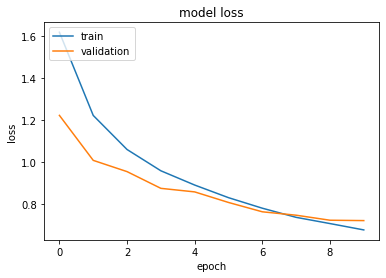

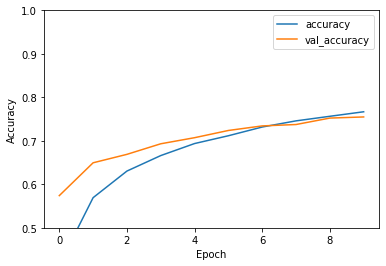

In [30]:
input_shape = (32,32,3)
model = model4(input_shape)
run_model(model)

Observation: 
* No more overfitting

**DATA AUGMENTATION**

In [0]:
def run_model_with_imagegenerator(model):
  model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  history = model.fit_generator(train_datagen.flow(train_images, train_labels,batch_size=64),
                        epochs=10,
                        validation_data=(test_images, test_labels))
  plotLosses(history)
  plotAccuracies(history)

Epoch 1/10
782/782 [==============================] - 40s 51ms/step - loss: 1.6382 - accuracy: 0.4044 - val_loss: 1.2288 - val_accuracy: 0.5634
Epoch 2/10
782/782 [==============================] - 40s 51ms/step - loss: 1.2851 - accuracy: 0.5435 - val_loss: 1.1176 - val_accuracy: 0.5945
Epoch 3/10
782/782 [==============================] - 40s 51ms/step - loss: 1.1569 - accuracy: 0.5951 - val_loss: 0.9670 - val_accuracy: 0.6655
Epoch 4/10
782/782 [==============================] - 41s 52ms/step - loss: 1.0698 - accuracy: 0.6237 - val_loss: 0.8995 - val_accuracy: 0.6779
Epoch 5/10
782/782 [==============================] - 40s 51ms/step - loss: 1.0237 - accuracy: 0.6442 - val_loss: 0.8598 - val_accuracy: 0.6974
Epoch 6/10
782/782 [==============================] - 40s 51ms/step - loss: 0.9788 - accuracy: 0.6610 - val_loss: 0.8875 - val_accuracy: 0.6882
Epoch 7/10
782/782 [==============================] - 40s 51ms/step - loss: 0.9549 - accuracy: 0.6708 - val_loss: 0.8290 - val_accuracy:

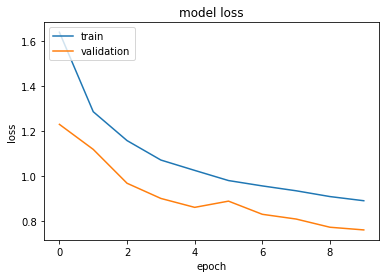

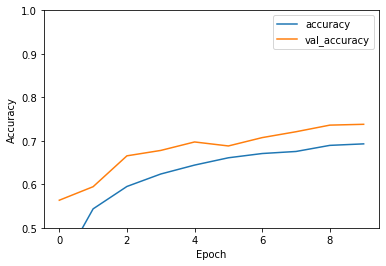

In [37]:
train_datagen = ImageDataGenerator(
        width_shift_range=0.1,  # Horizontal shift (10% of total width)
        height_shift_range=0.1,  # Vertical shift (10% of total height)
        horizontal_flip=True)   # flipping images horizontally . // Not advisable for medical data

train_datagen.fit(train_images)


input_shape = (32,32,3)
model = model4(input_shape)
run_model_with_imagegenerator(model)


Observation:
* Running model with image generator with batch_size = 128 gave an accuracy of 74%
*with batch_size = 32 , accuracy = 73%
Conclusion:
* with batch_size = 64 , epoch = 100 .accuracy = 81%


**More Data Augmentation**

Observation: Randomly adding augmentation doesnt help sometimes

Epoch 1/10
782/782 [==============================] - 401s 513ms/step - loss: 1.9954 - accuracy: 0.3266 - val_loss: 13.6872 - val_accuracy: 0.1411
Epoch 2/10
782/782 [==============================] - 360s 460ms/step - loss: 1.5597 - accuracy: 0.4396 - val_loss: 14.4210 - val_accuracy: 0.1041
Epoch 3/10
782/782 [==============================] - 322s 411ms/step - loss: 1.4278 - accuracy: 0.4890 - val_loss: 12.9619 - val_accuracy: 0.1665
Epoch 4/10
782/782 [==============================] - 286s 366ms/step - loss: 1.3268 - accuracy: 0.5274 - val_loss: 11.6339 - val_accuracy: 0.2552
Epoch 5/10
782/782 [==============================] - 338s 432ms/step - loss: 1.2465 - accuracy: 0.5591 - val_loss: 13.1917 - val_accuracy: 0.1750
Epoch 6/10
782/782 [==============================] - 301s 385ms/step - loss: 1.1959 - accuracy: 0.5747 - val_loss: 13.8875 - val_accuracy: 0.1324
Epoch 7/10
782/782 [==============================] - 286s 366ms/step - loss: 1.1464 - accuracy: 0.5963 - val_loss: 12

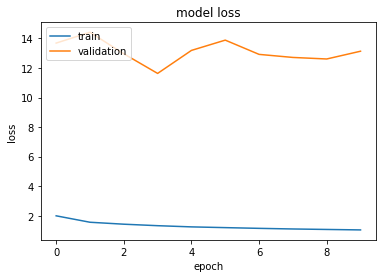

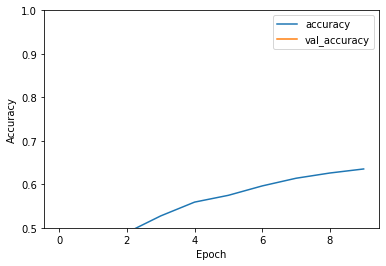

In [11]:
train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=45, # Rotation from 0-180deg
        zoom_range=0.5,
        width_shift_range=0.1,  # Horizontal shift (10% of total width)
        height_shift_range=0.1,  # Vertical shift (10% of total height)
        horizontal_flip=True)   # flipping images horizontally . // Not advisable for medical data

train_datagen.fit(train_images)


input_shape = (32,32,3)
model = model4(input_shape)
run_model_with_imagegenerator(model)

**Batch Normalization with deeper network and higher epoch**

In [0]:
#Model with dropouts and batch_normalisation to avoid overfitting
def model5(input_shape):
  layer_list = [tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape = input_shape),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape = input_shape),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Dropout(0.1), #Addition of layer here
                
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Dropout(0.1), #Addition of layer here
                
                  tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Dropout(0.25), #Addition of layer here
                  
                  tf.keras.layers.Flatten(),
                  tf.keras.layers.Dense(256, activation='relu'),
                  tf.keras.layers.BatchNormalization(axis=-1),
                  tf.keras.layers.Dropout(0.5),
                  tf.keras.layers.Dense(10, activation= 'softmax')]  

  model = tf.keras.Sequential(layer_list)
  return model

Epoch 1/50
782/782 [==============================] - 337s 430ms/step - loss: 1.6569 - accuracy: 0.4365 - val_loss: 1.2877 - val_accuracy: 0.5532
Epoch 2/50
782/782 [==============================] - 343s 438ms/step - loss: 1.1036 - accuracy: 0.6087 - val_loss: 1.1339 - val_accuracy: 0.6166
Epoch 3/50
782/782 [==============================] - 280s 358ms/step - loss: 0.9271 - accuracy: 0.6766 - val_loss: 1.1423 - val_accuracy: 0.6229
Epoch 4/50
782/782 [==============================] - 291s 372ms/step - loss: 0.8220 - accuracy: 0.7140 - val_loss: 0.8650 - val_accuracy: 0.7148
Epoch 5/50
782/782 [==============================] - 279s 357ms/step - loss: 0.7574 - accuracy: 0.7365 - val_loss: 0.7025 - val_accuracy: 0.7587
Epoch 6/50
782/782 [==============================] - 350s 448ms/step - loss: 0.6922 - accuracy: 0.7627 - val_loss: 0.6928 - val_accuracy: 0.7637
Epoch 7/50
782/782 [==============================] - 308s 394ms/step - loss: 0.6577 - accuracy: 0.7737 - val_loss: 0.6267 -

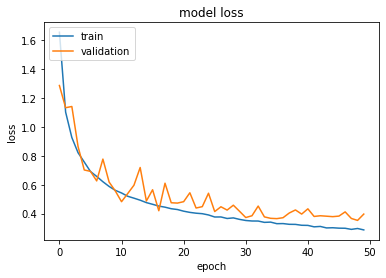

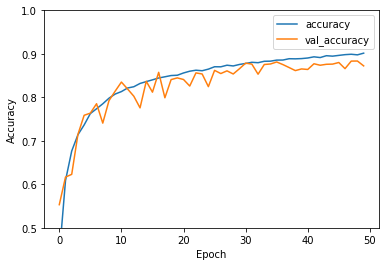

In [9]:
train_datagen = ImageDataGenerator(
        # rescale=1./255,
        rotation_range=10, # Rotation from 0-180deg
        # zoom_range=0.3,
        width_shift_range=0.1,  # Horizontal shift (10% of total width)
        height_shift_range=0.1,  # Vertical shift (10% of total height)
        horizontal_flip=True)   # flipping images horizontally . // Not advisable for medical data

train_datagen.fit(train_images)


input_shape = (32,32,3)
model = model5(input_shape)
run_model_with_imagegenerator(model)

Problems encountered:
* After 72 epochs the 12GB RAM of the server was full and the training stopped.
* Tried with local 16GB RAM

 Command:  jupyter notebook   --NotebookApp.allow_origin='https://colab.research.google.com'   --port=8888   --NotebookApp.port_retries=0


Observations:
* Having high dropout didnt help much. Tried with .5,.3,.25,
* Especially in early layers if dropout is less the model gave better accuracy.
* Having a low dropouts for early layers and high for dense layers gave better accuracy.
* 50 epochs gave an accuracy of 88%, 100 might have reached 90-91% is the guess.